In [2]:
import optuna

study = optuna.load_study(
    study_name='coupled_model',
    storage='sqlite:////Users/isakrockstrom/Desktop/Ocean/AML_proj/GRU_coupled_model/optuna_study.db'
)

print(f"Best value so far: {study.best_value}")
print(f"Best params: {study.best_params}")
print(f"Number of completed trials: {len(study.trials)}")


Best value so far: 0.2790049513084086
Best params: {'hidden_size_NN_AMOC': 128, 'num_layers_NN_AMOC': 2, 'dropout_NN_AMOC': 0.3859057648060895, 'lr_NN_AMOC': 0.0016022624670602131, 'hidden_size_NN_SFWF': 64, 'num_layers_NN_SFWF': 1, 'dropout_NN_SFWF': 0.09659394070264951, 'lr_NN_SFWF': 0.0009747224606968169, 'hidden_size_NN_PD_200m': 256, 'num_layers_NN_PD_200m': 3, 'dropout_NN_PD_200m': 0.397950951376891, 'lr_NN_PD_200m': 0.0028235128952228137, 'lag': 50, 'horizon': 50, 'rho': 0.46252563384991924, 'k': 0.49513840663505915}
Number of completed trials: 43


In [3]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

%load_ext autoreload
%autoreload 2

from data_helpers import prepare_this_data, torchify_this_data
from model_stuff import model_setup
from CoupledModel import CoupledModel

In [4]:
best = study.best_params

lag     = best['lag']
horizon = best['horizon']
rho     = best['rho']
k       = best['k']

model_configs = {
    'AMOC':    {'target_col': 'AMOC',    'feature_cols': ['SFWF', 'PD_200m']},
    'SFWF':    {'target_col': 'SFWF',    'feature_cols': ['AMOC', 'PD_200m']},
    'PD_200m': {'target_col': 'PD_200m', 'feature_cols': ['SFWF', 'AMOC']},
}

params = {
    'AMOC': {
        'hidden_size': best['hidden_size_NN_AMOC'],
        'num_layers':  best['num_layers_NN_AMOC'],
        'dropout':     best['dropout_NN_AMOC'],
        'lr':          best['lr_NN_AMOC'],
        'n_features':  2,
        'loss_fn':     torch.nn.MSELoss(),
    },
    'SFWF': {
        'hidden_size': best['hidden_size_NN_SFWF'],
        'num_layers':  best['num_layers_NN_SFWF'],
        'dropout':     best['dropout_NN_SFWF'],
        'lr':          best['lr_NN_SFWF'],
        'n_features':  2,
        'loss_fn':     torch.nn.MSELoss(),
    },
    'PD_200m': {
        'hidden_size': best['hidden_size_NN_PD_200m'],
        'num_layers':  best['num_layers_NN_PD_200m'],
        'dropout':     best['dropout_NN_PD_200m'],
        'lr':          best['lr_NN_PD_200m'],
        'n_features':  2,
        'loss_fn':     torch.nn.MSELoss(),
    },
}

X = pd.read_csv('../data/CESMDataset_Try.csv')
train_cut_1 = None
train_cut_2 = None
batch_size  = 128
n_epochs    = 20
device      = 'cpu'

trained_models = {}

for name, config in model_configs.items():
    X_train_lag, y_train_lag, X_eval_lag, y_eval_lag, y_scaler, x_scaler = prepare_this_data(
        X, config['target_col'], config['feature_cols'],
        train_cut_1, train_cut_2, lag, horizon
    )
    X_train_t, y_train_t, train_loader, X_eval_t, y_eval_t, eval_loader = torchify_this_data(
        batch_size, X_train_lag, y_train_lag
    )
    model, _, _ = model_setup(device, params[name], n_epochs, train_loader, eval_loader, eval=False)
    trained_models[name] = {'model': model, 'y_scaler': y_scaler, 'x_scaler': x_scaler}

coupled = CoupledModel.from_trained(trained_models)

In [17]:
horizon

50

In [18]:
rho = 0.3
k = 0.3

start_idx = 6500
models = ['AMOC', 'SFWF', 'PD_200m']
features = {
    'AMOC': ['SFWF', 'PD_200m'],
    'SFWF': ['AMOC', 'PD_200m'],
    'PD_200m': ['SFWF', 'AMOC'],
}
steps = 7000
threshold = 13

predictions = coupled.predict(device, X, start_idx, lag, horizon, models, features, steps, threshold, rho, k)

/Users/isakrockstrom/anaconda3/envs/ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/isakrockstrom/anaconda3/envs/ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/isakrockstrom/anaconda3/envs/ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [6]:
len(predictions['AMOC'])

7000

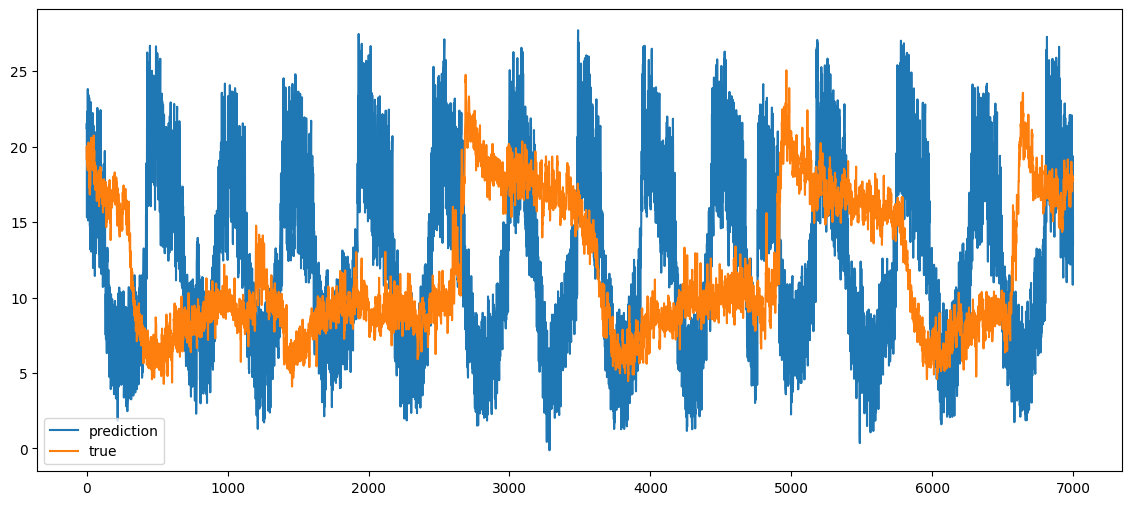

In [19]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14,6))

x = np.arange(steps)

plt.plot(x, predictions['AMOC'], label = 'prediction')
plt.plot(x, X['AMOC'][start_idx:start_idx+7000], label = 'true')
plt.legend()

In [9]:
len(X)

15796